In [6]:
# OVERFITTING AND REGULARIZATION
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping




In [10]:
# ============================================================
# 1. CREATE SMALL DATASET
# ============================================================

X, y = make_moons(
    n_samples=500,
    noise=0.25,
    random_state=42
)


# ============================================================
# 2. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# ============================================================
# 3. SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# ============================================================
# 4. OVERLY COMPLEX MODEL
# ============================================================

model = Sequential([

    Dense(
        128,
        activation="relu",
        input_shape=(2,)
    ),

    Dense(
        128,
        activation="relu"
    ),

    Dense(
        128,
        activation="relu"
    ),

    Dense(
        64,
        activation="relu"
    ),

    Dense(
        1,
        activation="sigmoid"
    )
])







/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


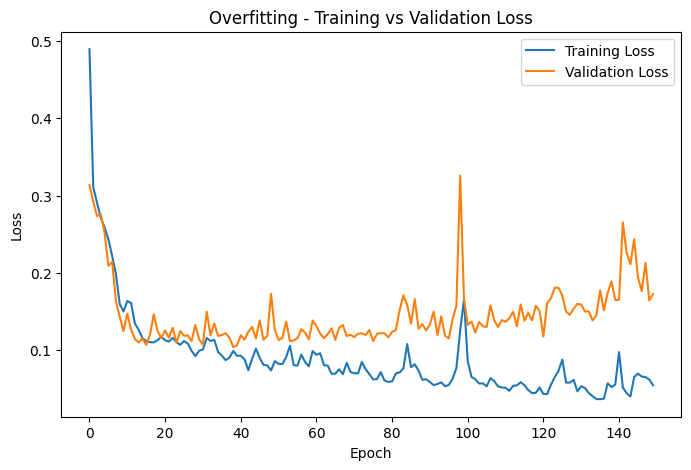

In [11]:
# 5. COMPILE
# ============================================================

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


# ============================================================
# 6. TRAIN
# ============================================================

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=150,
    batch_size=16,
    validation_split=0.2,
    verbose=0
)


# ============================================================
# 7. TRAINING / VALIDATION LOSS
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Overfitting - Training vs Validation Loss")
plt.legend()

plt.show()


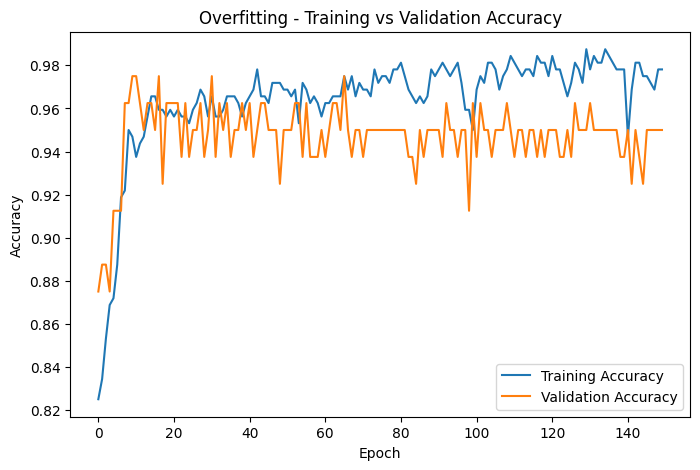

In [12]:
# 8. TRAINING / VALIDATION ACCURACY
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Overfitting - Training vs Validation Accuracy")
plt.legend()

plt.show()

In [13]:
# ============================================================
# 9. MODEL WITH DROPOUT + L2
# ============================================================

regularized_model = Sequential([

    Dense(
        128,
        activation="relu",
        kernel_regularizer=l2(0.001),
        input_shape=(2,)
    ),

    Dropout(0.3),

    Dense(
        128,
        activation="relu",
        kernel_regularizer=l2(0.001)
    ),

    Dropout(0.3),

    Dense(
        64,
        activation="relu",
        kernel_regularizer=l2(0.001)
    ),

    Dropout(0.2),

    Dense(
        1,
        activation="sigmoid"
    )
])


# ============================================================
# 10. COMPILE REGULARIZED MODEL
# ============================================================

regularized_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


# ============================================================
# 11. EARLY STOPPING
# ============================================================

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)


# ============================================================
# 12. TRAIN REGULARIZED MODEL
# ============================================================

regularized_history = regularized_model.fit(
    X_train_scaled,
    y_train,
    epochs=150,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=0
)


Regularized Model Test Loss: 0.15569335222244263
Regularized Model Test Accuracy: 0.9399999976158142


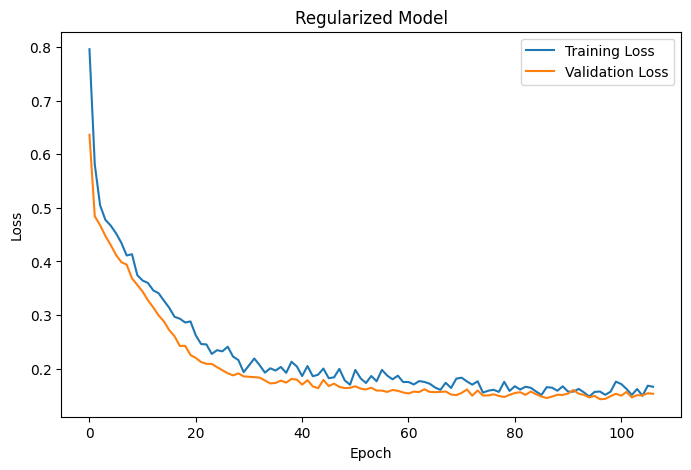

In [14]:

# ============================================================
# 13. REGULARIZED MODEL RESULTS
# ============================================================

test_loss, test_accuracy = regularized_model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("Regularized Model Test Loss:", test_loss)
print("Regularized Model Test Accuracy:", test_accuracy)


# ============================================================
# 14. REGULARIZED LOSS GRAPH
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    regularized_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    regularized_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Regularized Model")
plt.legend()

plt.show()